# Building Backtesting Framework and Performance Measurements

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Paths and Global Variables

In [2]:
note_path = os.getcwd()
repo_path = os.path.abspath(os.path.join(note_path, ".."))
data_path = os.path.join(repo_path, "data")
zone_path = os.path.join(data_path, "ZoneImputedFirstRateData")

In [3]:
day_renamer = {
    "day_after"   : "Day After",
    "day_before"  : "Day Before",
    "post_meeting": "Post Meeting",
    "pre_meeting" : "Pre Meeting"}

zone_renamer = {
    "zone1": "Day Before",
    "zone2": "Before Meeting",
    "zone3": "After Meeting",
    "zone4": "Day After"}

replacer = {**day_renamer, **zone_renamer}

# Calculating the backtest

One of the problems of generating PnL curves is the following
1. non-continuous times
2. each contract trading at different durations / vols and thus not normalized

In [4]:
path    = os.path.join(data_path, r"ZoneImputedFirstRateData")
df_zone = (pd
    .read_parquet(path = path)
    .loc[lambda x: x.ticker != "ZQ"]
    .set_index("date")
    [["meeting_id", "ticker", "contract", "impute_open", "zone", "name"]])

In [5]:
df_pnl = (df_zone
    .groupby(["meeting_id", "ticker", "contract", "zone", "name"])
    .apply(lambda x: x.sort_index().impute_open.diff())
    .reset_index())

Text(0.5, 1.0, 'Cumulative PnL of Volatility Targeted PnLs Hedged Perfectly and Minutely\nUsing 10d EWMA')

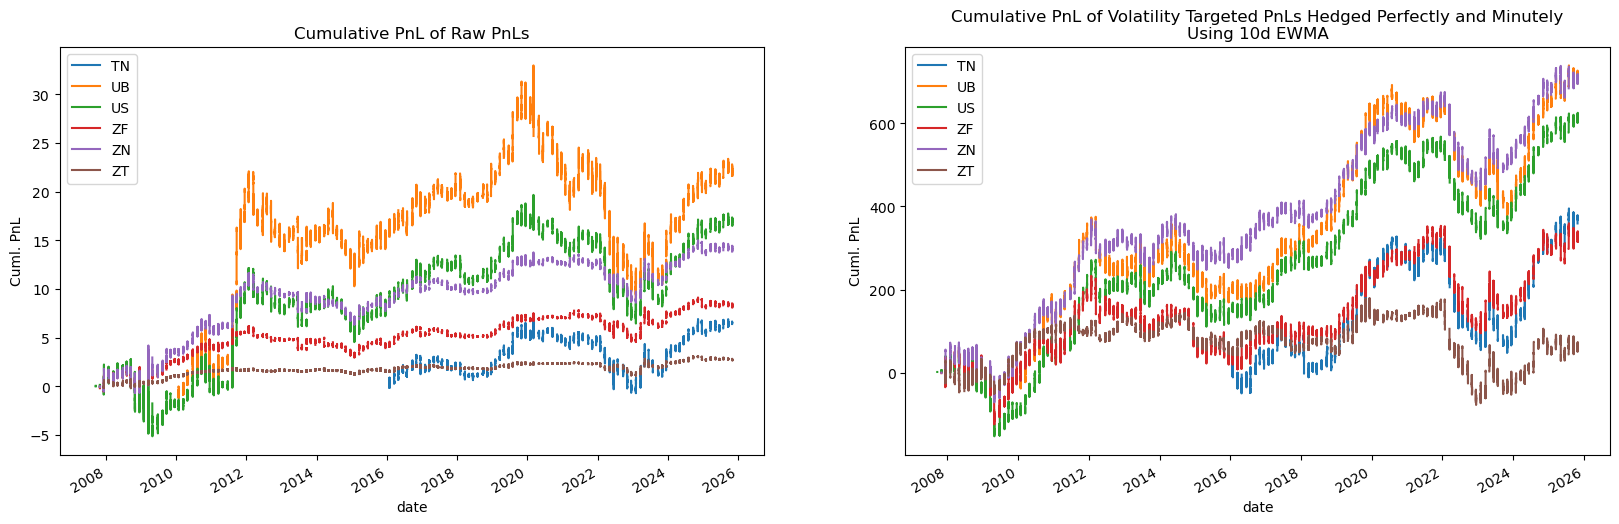

In [6]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_pnl
    .rename(columns = {"ticker": ""})
    .pivot(index = "date", columns = "", values = "impute_open")
    .cumsum()
    .plot(
        ax = axes[0]))

(df_pnl
    .rename(columns = {"ticker": ""})
    .pivot(index = "date", columns = "", values = "impute_open")
    .apply(lambda x: x / x.ewm(span = 10, adjust = False).std())
    .apply(lambda x: np.where(np.abs(x) > 50, np.nan, x))
    .cumsum()
    .plot(
        ax = axes[1]))

for ax in axes.flatten(): 
    ax.set_ylabel("Cuml. PnL")

axes[0].set_title("Cumulative PnL of Raw PnLs")
axes[1].set_title("Cumulative PnL of Volatility Targeted PnLs Hedged Perfectly and Minutely\nUsing 10d EWMA")

The PnLs need some sort of volatility targeting to noramlize the returns when we make the portfolio. On the other hand its not possible to hedge, and perfectly as well, at the minutely level. Therefore we need a volatility targeting tool that does the following
1. Calcluates a hedge value per every trade
2. Keeps the PnL in line with the initial hedge values
3. Also use the prior price action data (which isn't present in the trading zones) data, and thus properly hedge. 

# Finding the optimal volatility calculation

Ideally we want to find a volatility measurement that accurately sets a volatility target. Using the historical data, there are two options 
1. We can use the prior day's volatility calculation which comes from the data
2. We can use the prior event's volatility calculation

At this moment there are arguments for either since the prior day's volatility may capture the macro economic backdrop greater than the prior event, yet the whole point of this repo is to trade a repeatable pattern around FOMC announcements. 

In [7]:
df_event_vol = (df_pnl
    .drop(columns = ["date"])
    .groupby(["meeting_id", "ticker", "contract", "zone", "name"])
    .agg("std")
    .dropna()
    .reset_index()
    .rename(columns = {"impute_open": "vol"}))

In [8]:
df_lag_vol = (df_event_vol
    .set_index("meeting_id")
    .groupby(["ticker", "contract", "zone", "name"])
    .apply(lambda x: x.sort_index().vol.shift())
    .reset_index()
    .dropna()
    .rename(columns = {"vol": "lag_vol"}))

In [9]:
df_combined = (df_event_vol
    .merge(right = df_lag_vol, how = "inner", on = ["meeting_id", "ticker", "contract", "zone", "name"]))

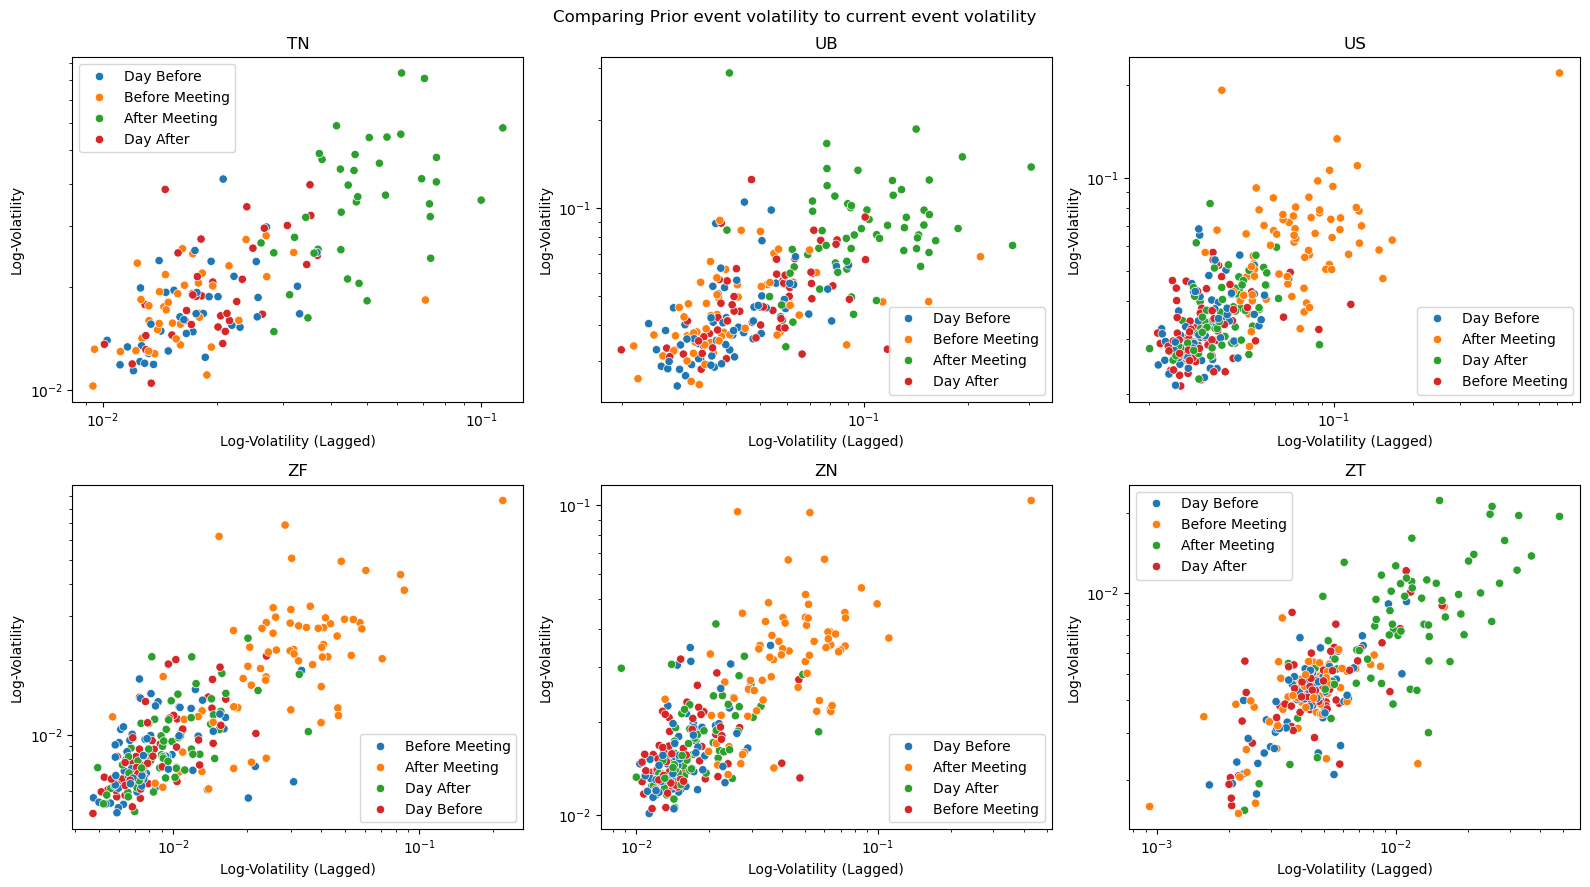

In [10]:
tickers = df_combined.ticker.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(tickers) // 2, nrows = 2, figsize = (16,9))

for ticker, ax in zip(tickers, axes.flatten()):

    df_tmp = (df_combined
        .loc[lambda x: x.ticker == ticker]
        .rename(columns = {"zone": ""})
        .replace(replacer))

    (sns.scatterplot(
        ax   = ax,
        data = df_tmp,
        x    = "lag_vol",
        y    = "vol",
        hue  = ""))

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Log-Volatility (Lagged)")
    ax.set_ylabel("Log-Volatility")
    ax.set_title(ticker)

fig.suptitle("Comparing Prior event volatility to current event volatility")
plt.tight_layout()

In [11]:
tickers = df_combined.ticker.drop_duplicates().sort_values().to_list()
models  = {}

for ticker in tickers: 

    df_tmp = (df_combined
        .loc[lambda x: x.ticker == ticker]
        .set_index("meeting_id")
        [["vol", "lag_vol"]]
        .apply(lambda x: np.log(x))
        .apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x))
        .apply(lambda x: np.where(x == 0, np.nan, x))
        .dropna())

    model = (sm
        .OLS(
            endog = df_tmp.vol,
            exog  = sm.add_constant(df_tmp.lag_vol))
        .fit())

    models[ticker] = model

C:\Users\Diego\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Diego\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Diego\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [12]:
df_param_list = []

for ticker in tickers:

    tmp_model = models[ticker]
    df_params = tmp_model.params.to_frame(name = "params").reset_index()
    df_tvalue = tmp_model.tvalues.to_frame(name = "tvalue").reset_index()
    df_pvalue = tmp_model.pvalues.to_frame(name = "p_value").reset_index()

    df_add = (df_params
        .merge(right = df_tvalue, how = "inner", on = ["index"])
        .merge(right = df_pvalue, how = "inner", on = ["index"])
        .assign(
            r2     = tmp_model.rsquared,
            ticker = ticker)
        .rename(columns = {"index": "param"}))
    
    df_param_list.append(df_add)

df_params = pd.concat(df_param_list)

In [13]:
(df_params
    .melt(id_vars = ["param", "ticker", "r2"])
    .pivot(index = ["ticker", "r2"], columns  = ["variable", "param"], values = "value"))

variable           params               tvalue                  p_value  \
param               const   lag_vol      const    lag_vol         const   
ticker r2                                                                 
TN     0.588407 -1.537149  0.613617  -9.661384  14.740991  1.633333e-17   
UB     0.454757 -1.326068  0.559931 -11.553452  14.439916  5.045090e-25   
US     0.493045 -1.405414  0.575178 -12.740763  16.794133  7.895339e-30   
ZF     0.632081 -1.702257  0.640711 -12.947550  21.893373  2.408964e-30   
ZN     0.580100 -1.649499  0.595033 -13.999310  19.807863  3.196406e-34   
ZT     0.628907 -2.022588  0.634962 -13.301382  21.977281  9.859281e-32   

variable                       
param                 lag_vol  
ticker r2                      
TN     0.588407  4.198410e-31  
UB     0.454757  8.817858e-35  
US     0.493045  1.103999e-44  
ZF     0.632081  1.584331e-62  
ZN     0.580100  1.900103e-55  
ZT     0.628907  2.662579e-63